In [1]:
!pip install openai python-dotenv -q

import pandas as pd
import os
import time
from openai import OpenAI
from dotenv import load_dotenv

In [2]:
%pip install openai python-dotenv

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 29.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 38.5 MB/s  0:00:00

   ------------- -------------------------- 3/9 [pydantic-core]
   ------------------------------- -------- 7/9 [pydantic]
   ------------------------------- -------- 7/9 [pydantic]
   ------------------------------- -------- 7/9 [pydantic]
   ------------------------------- -------- 7/9 [pydantic]
   ----------------------------------- ---- 8/9 [openai]
   ----------------------------------- ---- 8/9 [openai]
   ----------------------------------- ---- 8/9 [openai]
   ----------------------------------- ---- 8/9 [openai]
   ----------------------------------- ---- 8/9 [openai]
   ----------------------------------- ---- 8/9 [openai


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv("text_dataset.csv")
df.columns

FileNotFoundError: [Errno 2] No such file or directory: 'text_dataset.csv'

In [3]:
import os

[f for f in os.listdir() if f.endswith(".csv")]

[]

In [4]:
import os

os.listdir("../datasets")

['loremflickr_city_street_images',
 'openlibrary_urban_texts',
 'urban_architecture_facade_images']

In [5]:
os.listdir("../datasets/openlibrary_urban_texts")

['urban_books_texts.json']

In [6]:
df = pd.read_json("../datasets/openlibrary_urban_texts/urban_books_texts.json")

df.head()

,keyword,title,text
0,urban design,Urban design,"Title: Urban design. Author: Cliff Moughtin, J..."
1,urban design,Wuthering Heights,Title: Wuthering Heights. Author: Emily Bronte...
2,urban design,Hans Andersen's Fairy Tales,Title: Hans Andersen's Fairy Tales. Author: Ha...
3,urban design,Alice's Adventures in Wonderland,Title: Alice's Adventures in Wonderland. Autho...
4,urban design,The Canterbury Tales,Title: The Canterbury Tales. Author: Geoffrey ...


In [7]:
text_column = "text"

texts = df[text_column].dropna().astype(str).tolist()

len(texts), texts[0][:300]

(250, 'Title: Urban design. Author: Cliff Moughtin, J C Moughtin. Subjects: .')

In [8]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

OpenAIError: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable

In [9]:
import os
os.getcwd()

'F:\\UCL_Work\\DfPI_Final_Project\\notebooks'

In [10]:
from openai import OpenAI
import os

os.environ["OPENAI_API_KEY"] = "sk-你的key"

client = OpenAI()

In [11]:
def build_design_translation_prompt(text):
    return f"""
You are helping to create a structured design dataset.

Translate the text into design-oriented information.

Return ONLY valid JSON in this exact structure:

{{
  "emotional_tone": "",
  "spatial_atmosphere": "",
  "material_keywords": ["", "", ""],
  "colour_palette": ["", "", ""],
  "form_rules": ["", "", ""],
  "design_prompt": ""
}}

Text:
{text}
"""

In [12]:
test_prompt = build_design_translation_prompt(texts[0])

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": test_prompt}],
    temperature=0.7
)

print(response.choices[0].message.content)

UnicodeEncodeError: 'ascii' codec can't encode characters in position 10-11: ordinal not in range(128)

In [13]:
def build_design_translation_prompt(text):
    clean_text = text.encode("ascii", errors="ignore").decode()

    return f"""
You are helping to create a structured design dataset.

IMPORTANT:
- Use ONLY English
- Do not include any special characters

Return ONLY valid JSON in this exact structure:

{{
  "emotional_tone": "",
  "spatial_atmosphere": "",
  "material_keywords": ["", "", ""],
  "colour_palette": ["", "", ""],
  "form_rules": ["", "", ""],
  "design_prompt": ""
}}

Text:
{clean_text}
"""

In [14]:
test_prompt = build_design_translation_prompt(texts[0])

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": test_prompt}],
    temperature=0.7
)

print(response.choices[0].message.content)

UnicodeEncodeError: 'ascii' codec can't encode characters in position 10-11: ordinal not in range(128)

In [1]:
from openai import OpenAI
import os

os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY"

client = OpenAI()

In [16]:
from openai import OpenAI
import os

os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY"

client = OpenAI()

In [18]:
test_prompt = build_design_translation_prompt(texts[0])

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": test_prompt}],
    temperature=0.7
)

print(response.choices[0].message.content)

{
  "emotional_tone": "innovative",
  "spatial_atmosphere": "dynamic",
  "material_keywords": ["concrete", "glass", "steel"],
  "colour_palette": ["grey", "blue", "green"],
  "form_rules": ["functional", "open", "modular"],
  "design_prompt": "Create a vibrant urban space that encourages community interaction while incorporating sustainable materials."
}


In [19]:
import json
import time
import pandas as pd

results = []

for i, text in enumerate(texts[:20]):
    prompt = build_design_translation_prompt(text)

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7
        )

        content = response.choices[0].message.content

        # 尝试解析 JSON
        try:
            data = json.loads(content)
        except:
            data = {
                "emotional_tone": "",
                "spatial_atmosphere": "",
                "material_keywords": [],
                "colour_palette": [],
                "form_rules": [],
                "design_prompt": content
            }

        results.append({
            "id": i,
            "source": "api_design",
            "original_text": text,
            "emotional_tone": data.get("emotional_tone", ""),
            "spatial_atmosphere": data.get("spatial_atmosphere", ""),
            "material_keywords": ", ".join(data.get("material_keywords", [])),
            "colour_palette": ", ".join(data.get("colour_palette", [])),
            "form_rules": " | ".join(data.get("form_rules", [])),
            "design_prompt": data.get("design_prompt", "")
        })

        print(f"Done {i+1}/20")
        time.sleep(1)

    except Exception as e:
        print(f"Error at {i}: {e}")

Done 1/20
Done 2/20
Done 3/20
Done 4/20
Done 5/20
Done 6/20
Done 7/20
Done 8/20
Done 9/20
Done 10/20
Done 11/20
Done 12/20
Done 13/20
Done 14/20
Done 15/20
Done 16/20
Done 17/20
Done 18/20
Done 19/20
Done 20/20


In [20]:
api_df = pd.DataFrame(results)

api_df.to_csv("api_design_dataset.csv", index=False)

api_df.head()

,id,source,original_text,emotional_tone,spatial_atmosphere,material_keywords,colour_palette,form_rules,design_prompt
0,0,api_design,"Title: Urban design. Author: Cliff Moughtin, J...",innovative,dynamic,"concrete, glass, steel","grey, blue, green",functional | modular | open,Create a vibrant urban space that encourages c...
1,1,api_design,Title: Wuthering Heights. Author: Emily Bronte...,"dark, passionate, tumultuous","rugged, isolated, stormy","wood, stone, fabric","grey, green, black",asymmetrical | organic | textured,Create a design inspired by the contrasting em...
2,2,api_design,Title: Hans Andersen's Fairy Tales. Author: Ha...,whimsical,enchanted,"paper, ink, illustration","pastel, gold, blue",storybook layout | ornate borders | illustrati...,Create a whimsical book cover for Hans Anderse...
3,3,api_design,Title: Alice's Adventures in Wonderland. Autho...,whimsical,surreal,"paper, fabric, wood","vibrant, pastel, earthy",organic shapes | asymmetry | layering,Create a whimsical design inspired by Alice's ...
4,4,api_design,Title: The Canterbury Tales. Author: Geoffrey ...,reflective,medieval,"parchment, ink, quill","earth tones, gold, deep red",narrative structure | character development | ...,Create a book cover that reflects the medieval...


In [21]:
original_df = pd.DataFrame({
    "text": texts[:20],
    "source": "original_text"
})

api_text_df = pd.DataFrame({
    "text": api_df["design_prompt"],
    "source": "api_design_prompt"
})

combined_df = pd.concat([original_df, api_text_df], ignore_index=True)

combined_df.head()

,text,source
0,"Title: Urban design. Author: Cliff Moughtin, J...",original_text
1,Title: Wuthering Heights. Author: Emily Bronte...,original_text
2,Title: Hans Andersen's Fairy Tales. Author: Ha...,original_text
3,Title: Alice's Adventures in Wonderland. Autho...,original_text
4,Title: The Canterbury Tales. Author: Geoffrey ...,original_text


In [22]:
combined_df["source"].value_counts()

source
original_text        20
api_design_prompt    20
Name: count, dtype: int64

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=150,
    stop_words="english"
)

tfidf_vectors = tfidf_vectorizer.fit_transform(combined_df["text"])

tfidf_vectors.shape

(40, 142)

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

tfidf_pca = pca.fit_transform(tfidf_vectors.toarray())

tfidf_pca[:5]

array([[-0.36486845,  0.40195129],
       [-0.24758967, -0.10506156],
       [-0.19175596, -0.35623367],
       [-0.22828626, -0.13562181],
       [-0.21917846, -0.19487702]])

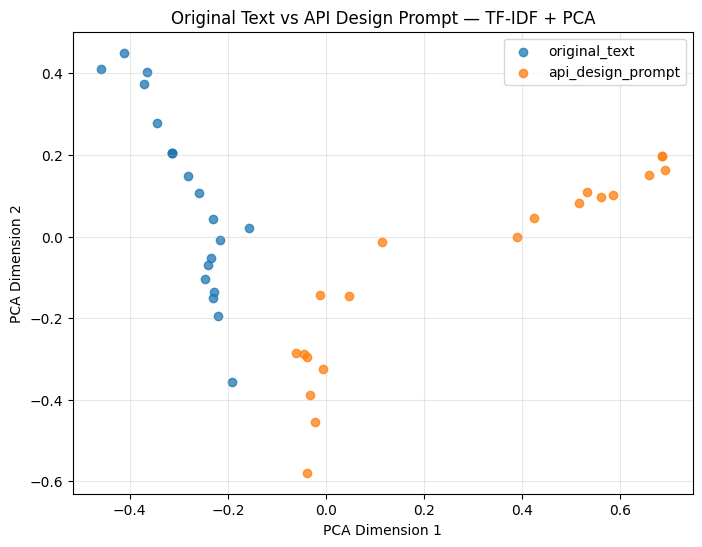

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for label in combined_df["source"].unique():
    idx = combined_df["source"] == label
    plt.scatter(
        tfidf_pca[idx, 0],
        tfidf_pca[idx, 1],
        label=label,
        alpha=0.75
    )

plt.title("Original Text vs API Design Prompt — TF-IDF + PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

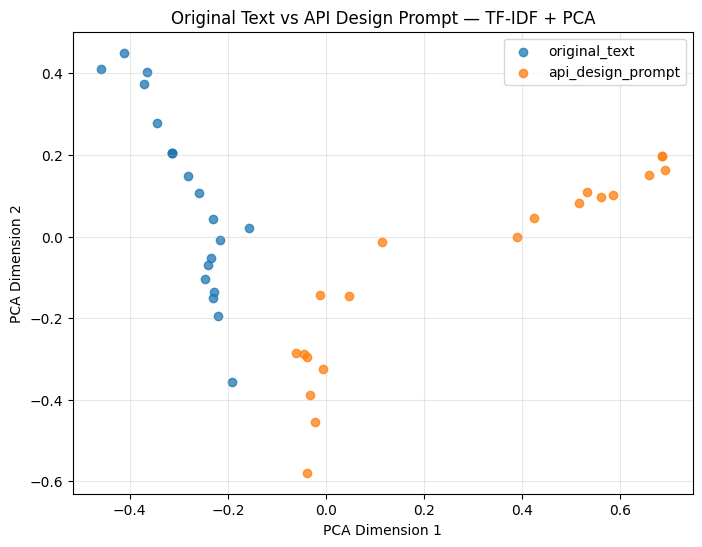

In [26]:
plt.figure(figsize=(8, 6))

for label in combined_df["source"].unique():
    idx = combined_df["source"] == label
    plt.scatter(
        tfidf_pca[idx, 0],
        tfidf_pca[idx, 1],
        label=label,
        alpha=0.75
    )

plt.title("Original Text vs API Design Prompt — TF-IDF + PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("tfidf_original_vs_api_pca.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
import pandas as pd

api_df = pd.read_csv("api_design_dataset.csv")
api_df.head()

,id,source,original_text,emotional_tone,spatial_atmosphere,material_keywords,colour_palette,form_rules,design_prompt
0,0,api_design,"Title: Urban design. Author: Cliff Moughtin, J...",innovative,dynamic,"concrete, glass, steel","grey, blue, green",functional | modular | open,Create a vibrant urban space that encourages c...
1,1,api_design,Title: Wuthering Heights. Author: Emily Bronte...,"dark, passionate, tumultuous","rugged, isolated, stormy","wood, stone, fabric","grey, green, black",asymmetrical | organic | textured,Create a design inspired by the contrasting em...
2,2,api_design,Title: Hans Andersen's Fairy Tales. Author: Ha...,whimsical,enchanted,"paper, ink, illustration","pastel, gold, blue",storybook layout | ornate borders | illustrati...,Create a whimsical book cover for Hans Anderse...
3,3,api_design,Title: Alice's Adventures in Wonderland. Autho...,whimsical,surreal,"paper, fabric, wood","vibrant, pastel, earthy",organic shapes | asymmetry | layering,Create a whimsical design inspired by Alice's ...
4,4,api_design,Title: The Canterbury Tales. Author: Geoffrey ...,reflective,medieval,"parchment, ink, quill","earth tones, gold, deep red",narrative structure | character development | ...,Create a book cover that reflects the medieval...


In [5]:
original_df = pd.DataFrame({
    "text": api_df["original_text"],
    "source": "original_text"
})

api_text_df = pd.DataFrame({
    "text": api_df["design_prompt"],
    "source": "api_design_prompt"
})

combined_df = pd.concat([original_df, api_text_df], ignore_index=True)

combined_df.head()

,text,source
0,"Title: Urban design. Author: Cliff Moughtin, J...",original_text
1,Title: Wuthering Heights. Author: Emily Bronte...,original_text
2,Title: Hans Andersen's Fairy Tales. Author: Ha...,original_text
3,Title: Alice's Adventures in Wonderland. Autho...,original_text
4,Title: The Canterbury Tales. Author: Geoffrey ...,original_text


In [6]:
combined_df["source"].value_counts()

source
original_text        20
api_design_prompt    20
Name: count, dtype: int64

In [7]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

documents = []

for i, row in combined_df.iterrows():
    tokens = row["text"].lower().split()
    documents.append(TaggedDocument(words=tokens, tags=[str(i)]))

len(documents)

40

In [8]:
doc2vec_model = Doc2Vec(
    vector_size=50,
    window=5,
    min_count=1,
    workers=4,
    epochs=40
)

doc2vec_model.build_vocab(documents)

doc2vec_model.train(
    documents,
    total_examples=doc2vec_model.corpus_count,
    epochs=doc2vec_model.epochs
)

In [9]:
from sklearn.decomposition import PCA

doc_vectors = [doc2vec_model.dv[str(i)] for i in range(len(documents))]

pca = PCA(n_components=2)
doc2vec_pca = pca.fit_transform(doc_vectors)

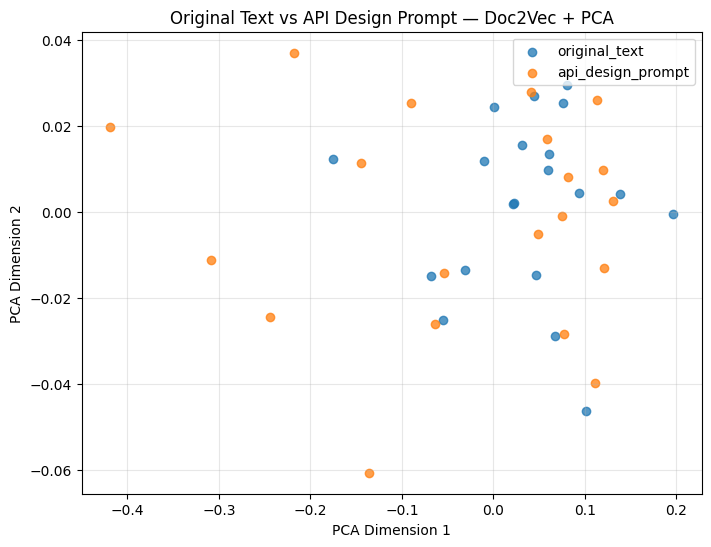

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for label in combined_df["source"].unique():
    idx = combined_df["source"] == label
    plt.scatter(
        doc2vec_pca[idx, 0],
        doc2vec_pca[idx, 1],
        label=label,
        alpha=0.75
    )

plt.title("Original Text vs API Design Prompt — Doc2Vec + PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("doc2vec_original_vs_api_pca.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
from sklearn.cluster import KMeans

# 设3类（很关键，对应后面3个workflow）
kmeans = KMeans(n_clusters=3, random_state=42)

cluster_labels = kmeans.fit_predict(doc_vectors)

# 把结果加回 dataframe
combined_df["cluster"] = cluster_labels

combined_df.head()

,text,source,cluster
0,"Title: Urban design. Author: Cliff Moughtin, J...",original_text,0
1,Title: Wuthering Heights. Author: Emily Bronte...,original_text,0
2,Title: Hans Andersen's Fairy Tales. Author: Ha...,original_text,2
3,Title: Alice's Adventures in Wonderland. Autho...,original_text,2
4,Title: The Canterbury Tales. Author: Geoffrey ...,original_text,2


In [12]:
combined_df.groupby(["cluster", "source"]).size()

cluster  source           
0        api_design_prompt    11
         original_text        14
1        api_design_prompt     4
         original_text         1
2        api_design_prompt     5
         original_text         5
dtype: int64

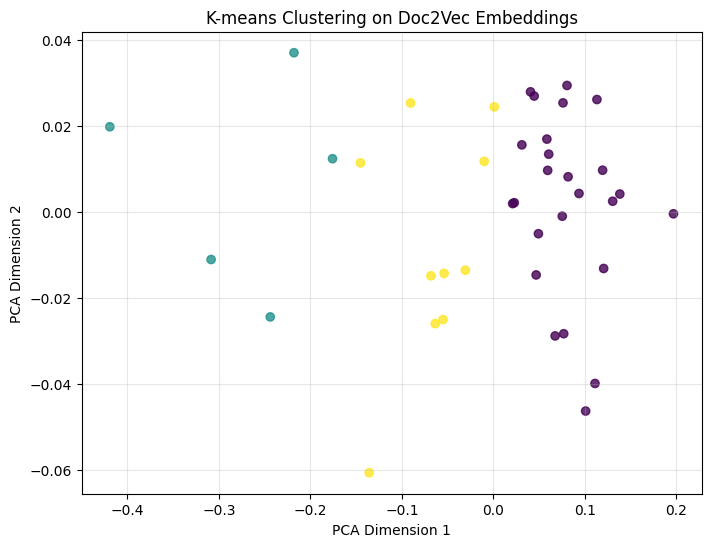

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    doc2vec_pca[:, 0],
    doc2vec_pca[:, 1],
    c=combined_df["cluster"],
    cmap="viridis",
    alpha=0.8
)

plt.title("K-means Clustering on Doc2Vec Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True, alpha=0.3)

plt.show()

In [15]:
print("=== Cluster 0 ===")
print(combined_df[combined_df["cluster"] == 0]["text"].head(5))

print("\n=== Cluster 1 ===")
print(combined_df[combined_df["cluster"] == 1]["text"].head(5))

print("\n=== Cluster 2 ===")
print(combined_df[combined_df["cluster"] == 2]["text"].head(5))

=== Cluster 0 ===
0    Title: Urban design. Author: Cliff Moughtin, J...
1    Title: Wuthering Heights. Author: Emily Bronte...
6    Title: The Picture of Dorian Gray. Author: Osc...
7    Title: The Sea-Wolf. Author: Jack London. Subj...
8    Title: Urban design. Author: Cliff Moughtin. S...
Name: text, dtype: object

=== Cluster 1 ===
19    Title: The comprehensive plan : urban design. ...
22    Create a whimsical book cover for Hans Anderse...
23    Create a whimsical design inspired by Alice's ...
26    Create a visual representation that captures t...
27    Create a design inspired by the adventurous sp...
Name: text, dtype: object

=== Cluster 2 ===
2     Title: Hans Andersen's Fairy Tales. Author: Ha...
3     Title: Alice's Adventures in Wonderland. Autho...
4     Title: The Canterbury Tales. Author: Geoffrey ...
5     Title: The Great Gatsby. Author: F. Scott Fitz...
10    Title: A New theory of urban design. Author: C...
Name: text, dtype: object


In [25]:
# cluster_labels 一共有40个：
# 前20个是 original_text，后20个是 api_design_prompt
api_df["cluster"] = cluster_labels[20:]

api_df.head()

,id,source,original_text,emotional_tone,spatial_atmosphere,material_keywords,colour_palette,form_rules,design_prompt,cluster
0,0,api_design,"Title: Urban design. Author: Cliff Moughtin, J...",innovative,dynamic,"concrete, glass, steel","grey, blue, green",functional | modular | open,Create a vibrant urban space that encourages c...,0
1,1,api_design,Title: Wuthering Heights. Author: Emily Bronte...,"dark, passionate, tumultuous","rugged, isolated, stormy","wood, stone, fabric","grey, green, black",asymmetrical | organic | textured,Create a design inspired by the contrasting em...,2
2,2,api_design,Title: Hans Andersen's Fairy Tales. Author: Ha...,whimsical,enchanted,"paper, ink, illustration","pastel, gold, blue",storybook layout | ornate borders | illustrati...,Create a whimsical book cover for Hans Anderse...,1
3,3,api_design,Title: Alice's Adventures in Wonderland. Autho...,whimsical,surreal,"paper, fabric, wood","vibrant, pastel, earthy",organic shapes | asymmetry | layering,Create a whimsical design inspired by Alice's ...,1
4,4,api_design,Title: The Canterbury Tales. Author: Geoffrey ...,reflective,medieval,"parchment, ink, quill","earth tones, gold, deep red",narrative structure | character development | ...,Create a book cover that reflects the medieval...,2


In [26]:
api_df[[
    "original_text",
    "design_prompt",
    "cluster",
    "material_keywords",
    "colour_palette",
    "form_rules"
]].to_csv("part2_design_rules_FINAL.csv", index=False)

In [27]:
part2_rules = pd.read_csv("part2_design_rules_FINAL.csv")
part2_rules.head()

,original_text,design_prompt,cluster,material_keywords,colour_palette,form_rules
0,"Title: Urban design. Author: Cliff Moughtin, J...",Create a vibrant urban space that encourages c...,0,"concrete, glass, steel","grey, blue, green",functional | modular | open
1,Title: Wuthering Heights. Author: Emily Bronte...,Create a design inspired by the contrasting em...,2,"wood, stone, fabric","grey, green, black",asymmetrical | organic | textured
2,Title: Hans Andersen's Fairy Tales. Author: Ha...,Create a whimsical book cover for Hans Anderse...,1,"paper, ink, illustration","pastel, gold, blue",storybook layout | ornate borders | illustrati...
3,Title: Alice's Adventures in Wonderland. Autho...,Create a whimsical design inspired by Alice's ...,1,"paper, fabric, wood","vibrant, pastel, earthy",organic shapes | asymmetry | layering
4,Title: The Canterbury Tales. Author: Geoffrey ...,Create a book cover that reflects the medieval...,2,"parchment, ink, quill","earth tones, gold, deep red",narrative structure | character development | ...


In [29]:
combined_df[[
    "original_text",
    "design_prompt",
    "cluster",
    "material_keywords",
    "colour_palette",
    "form_rules"
]].to_csv("c4d_input.csv", index=False)